In [4]:
from matplotlib import pyplot as plt 
import numpy as np 

from pathlib import Path

In [5]:
DATA_DIR = Path("../../tmp/toy-experiments")

In [14]:
ls -la ../../tmp/toy-experiments/toy-dataset-eps0.01-seed1

total 968
drwxr-xr-x 3 pat pat   4096 May 22 11:20 ./
drwxr-xr-x 3 pat pat   4096 May 22 11:20 ../
drwxr-xr-x 3 pat pat   4096 May 22 11:20 lightning_logs/
-rw-r--r-- 1 pat pat    152 May 22 11:20 mean.npy
-rw-r--r-- 1 pat pat    152 May 22 11:20 meta.json
-rw-r--r-- 1 pat pat    152 May 22 11:20 std.npy
-rw-r--r-- 1 pat pat 576128 May 22 11:20 x_train.npy
-rw-r--r-- 1 pat pat 144128 May 22 11:20 x_val.npy
-rw-r--r-- 1 pat pat 192128 May 22 11:20 y_train.npy
-rw-r--r-- 1 pat pat  48128 May 22 11:20 y_val.npy


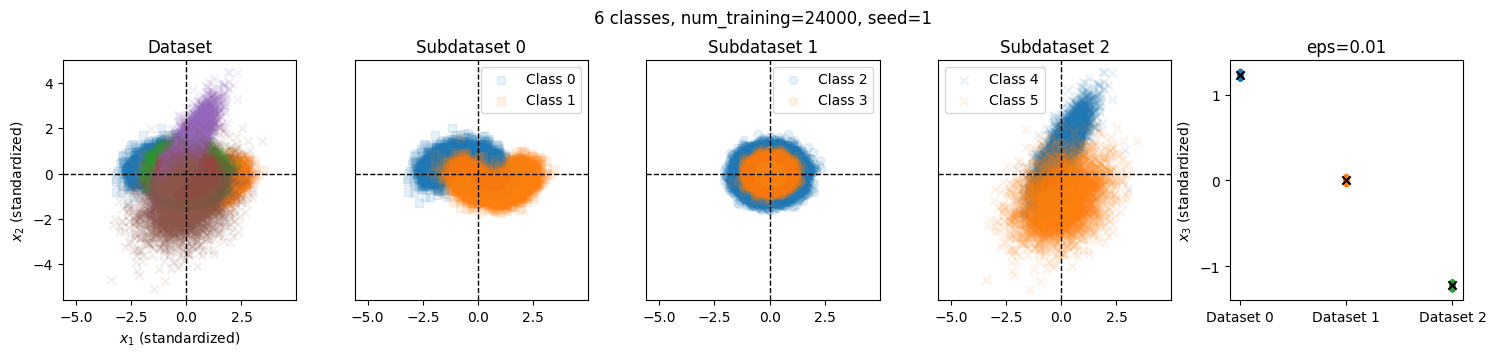

In [61]:
def viz_dataset(eps, seed):
    
    X_train = np.load(DATA_DIR / f"toy-dataset-eps{eps}-seed{seed}" / "x_train.npy")
    y_train = np.load(DATA_DIR / f"toy-dataset-eps{eps}-seed{seed}" / "y_train.npy")
    
    ncols = 5

    vmin, vmax = np.min(X_train[:, :2]), np.max(X_train[:, :2])
    vmin -= 0.5
    vmax += 0.5
    plt.figure(figsize=(ncols*3.5, 3))

    total_classes = len(set(y_train))

    
    plt.suptitle(f"{total_classes} classes, num_training={X_train.shape[0]}, seed={seed}", y=1.07)

    plt.subplot(1, ncols, 1)
    plt.title("Dataset")
    plt.xlim([vmin, vmax]); plt.ylim([vmin, vmax])
    
    markers = ["s", "o", "x"]

    plt.axhline(0, ls='--', color="k", lw=1); plt.axvline(0, ls='--', color="k", lw=1)

    for group in range(0, 6, 2):
        pos = y_train == group
        neg = y_train == (group + 1)

        plt.scatter(X_train[pos, 0], X_train[pos, 1], label=f"Group {group}: Pos", marker=markers[group//2], alpha=0.1)
        plt.scatter(X_train[neg, 0], X_train[neg, 1], label=f"Group {group}: Neg", marker=markers[group//2], alpha=0.1)

    plt.xlabel("$x_1$ (standardized)")
    plt.ylabel("$x_2$ (standardized)")


    for group in range(0, 6, 2):
        plt.subplot(1, ncols, group //2 + 2)
        plt.axhline(0, ls='--', color="k", lw=1); plt.axvline(0, ls='--', color="k", lw=1)

        plt.title(f"Subdataset {group // 2}")
        plt.xlim([vmin, vmax]); plt.ylim([vmin, vmax])

        c1, c2 = group, group+1
        pos = y_train == c1
        neg = y_train == c2

        plt.scatter(
            X_train[pos, 0], X_train[pos, 1], label=f"Class {c1}", marker=markers[group//2], alpha=0.1,
        )
        plt.scatter(
            X_train[neg, 0], X_train[neg, 1], label=f"Class {c2}", marker=markers[group//2], alpha=0.1,
        )
        plt.legend()
        plt.yticks([])

    plt.subplot(1, ncols, 5)
    plt.title(f"eps={eps}")

    for group in range(0, 6, 2):
        _x = X_train[np.isin(y_train, [group, group+1]), :]
        plt.scatter([group//2] * _x.shape[0], _x[:, 2], alpha=0.5, marker='.')  
        plt.scatter([group//2], [_x[:, 2].mean()], marker="x", color="k")
    
    plt.ylabel("$x_3$ (standardized)")

    ticks = list(range(3))
    plt.xticks(ticks, list(map(lambda t: f"Dataset {t}", ticks)))
    plt.yticks([-1, 0, 1])
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.25,hspace=0.0)

viz_dataset(eps=0.01, seed=1)

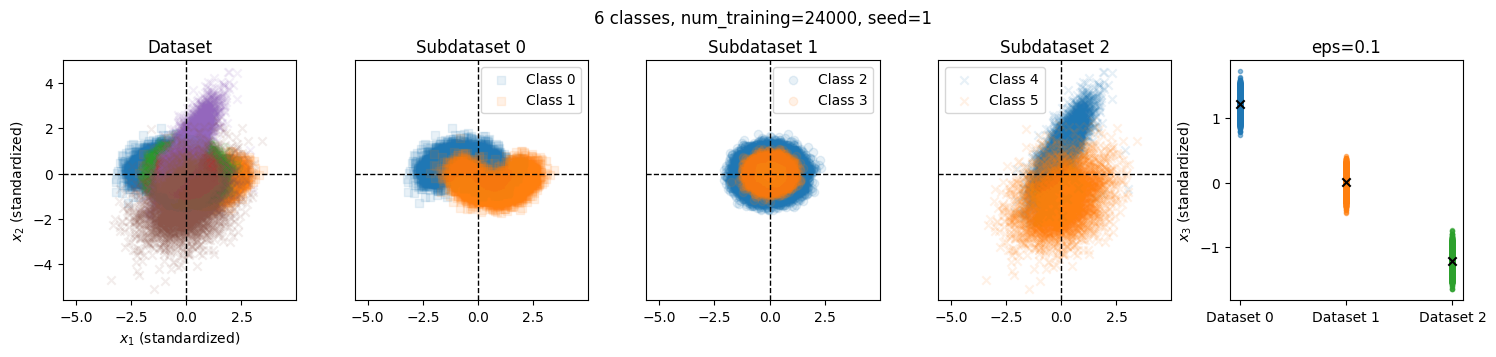

In [62]:
viz_dataset(eps=0.1, seed=1)

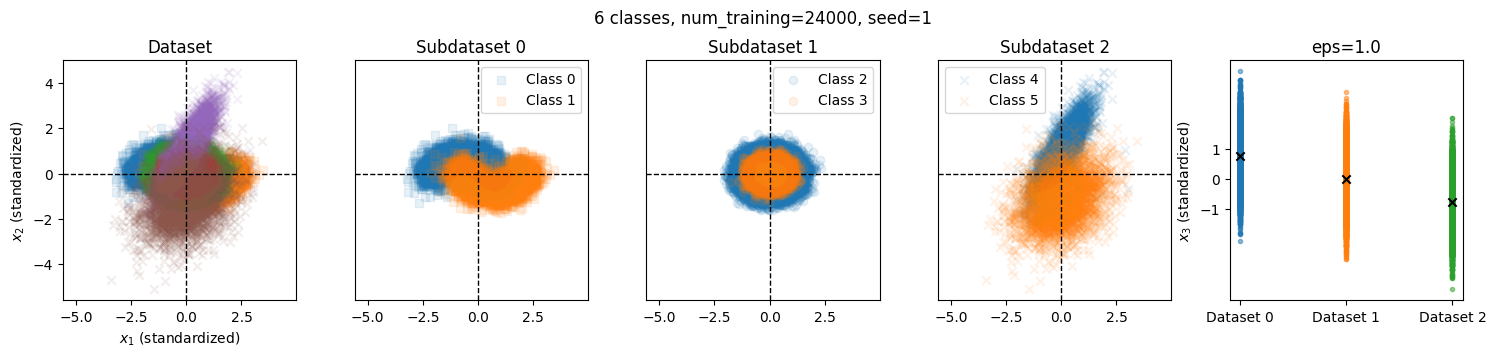

In [65]:
viz_dataset(eps=1.0, seed=1)

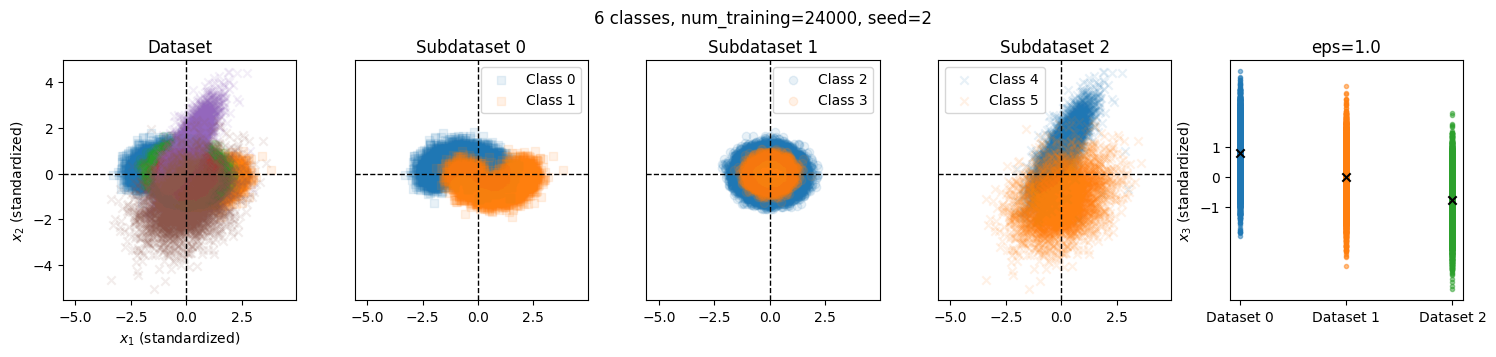

In [66]:
viz_dataset(eps=1.0, seed=2)